In [6]:
""" Imports and Setup. """
import sys
import pandas as pd
import numpy as np
sys.path.append("/Users/emilieyu/endotehelial-masboss")
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpatches 
import copy

from src.config import load_sim_config, load_sweep_config, load_spatial_config
from src.paths import BM_RESULTS_DIR

sim_cfg = load_sim_config()
sweep_cfg = load_sweep_config()
spatial_cfg = load_spatial_config()

from abm.flow_field import FlowField
from abm.endothelial_cell import EndothelialCell
from abm.membrane_node import MembraneNode
from abm.spring import Spring
from abm.rho_lookup_table import RhoLookupTable
from abm.abm_helpers import classify_phenotype

def check(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    print(f"  [{status}] {name}" + (f" — {detail}" if detail else ""))
    return condition

lut = RhoLookupTable(spatial_cfg, BM_RESULTS_DIR)   

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


## Functions

In [ ]:
""" Single Cell Full Pipeline Simulation """
def run_single_cell_sim(cell, flow):
    print(f"Starting: {cell}\n")
        
    history = []
    for t in range(500):
        cell.step(flow, dt=0.1)
        if t % 10 == 0:
                s = cell.get_state()
                s['step'] = t
                history.append(s)
                if t % 100 == 0:
                    print(f"  step {t:4d}: {cell}")
        # if t % 100 == 0: 
        #         lateral_stretched = sum(1 for s in cell.springs
        #                 if s.alignment > 0.5 and s.L_current > s.L_cortex)
        #         print(f"  step {t:4d}: {cell} | lateral springs stretched: {lateral_stretched}/~4")
            

    final = history[-1]
    print(f"\nFinal: {cell}")

    # Pass/fail checks
    print("\n--- Checks ---")
    check("AR > 1.3 at steady state",
        final['metrics']['ar'] > 1.3,
        f"ar={final['metrics']['ar']}")
    check("area_err within 15%",
        abs(final['metrics']['area_err'] - 1.0) < 0.15,
        f"area_err={final['metrics']['area_err']}")
    check("L_sf has shortened on lateral springs",
        final['remodelling']['mean_lsf_ratio'] < 1.0,
        f"lsf={final['remodelling']['mean_lsf_ratio']:.4f}")
    check("rho_balance not strongly negative",
        final['signalling']['rho_balance'] > -0.05,
        f"balance={final['signalling']['rho_balance']}")
    
    return history

### Plotting Functions

In [41]:
""" Plotting Functions """
def plot_cell(cell):
    pos = cell.positions
    x, y = pos[:, 0], pos[:, 1]
    c = cell.centroid

    plt.figure()
    plt.scatter(x, y)
    for node, (xi, yi) in zip(cell.nodes, pos):
        plt.text(xi, yi, str(node.id), fontsize=9, ha='right', va='bottom')

    plt.scatter(c[0]+0.2, c[1]+0.2, marker='x', s=100)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    plt.close()

def plot_run_results(history, pertubation=''):
    steps       = [h['step']                          for h in history]
    ars         = [h['metrics']['ar']                 for h in history]
    area_errs   = [h['metrics']['area_err']           for h in history]
    rho_balance = [h['signalling']['rho_balance']     for h in history]
    lateral_rc  = [h['signalling']['lateral_rhoc']    for h in history]
    t_sf        = [h['mechanics']['t_sf']             for h in history]
    t_cortex    = [h['mechanics']['t_cortex']         for h in history]
    lsf_ratio   = [h['remodelling']['mean_lsf_ratio'] for h in history]
    k_active    = [h['remodelling']['mean_k_active']  for h in history]

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    # AR
    axes[0].plot(steps, ars, color='steelblue', linewidth=1.5, label='AR')
    axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].fill_between(steps, 1.0, ars, alpha=0.1, color='steelblue')
    axes[0].set_ylabel("Aspect ratio")
    axes[0].set_title(f"Single cell — 500 steps, {pertubation}")
    axes[0].legend(fontsize=9)

    # Tension split
    axes[1].plot(steps, t_sf,     color='#1D9E75', linewidth=1.5, label='t_sf (fibre, RhoC)')
    axes[1].plot(steps, t_cortex, color='#E24B4A', linewidth=1.5, label='t_cortex (cortex, RhoA)')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel("Mean tension")
    axes[1].legend(fontsize=9)

    # Rho signalling
    axes[2].plot(steps, rho_balance, color='#7F77DD', linewidth=1.5, label='RhoC − RhoA (balance)')
    axes[2].plot(steps, lateral_rc,  color='#1D9E75', linewidth=1.5,
                linestyle='--', label='lateral RhoC')
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[2].set_ylabel("Rho activity")
    axes[2].legend(fontsize=9)

    # Remodelling state
    axes[3].plot(steps, lsf_ratio, color='#BA7517', linewidth=1.5, label='L_sf/L_cortex')
    axes[3].plot(steps, k_active,  color='#E24B4A', linewidth=1.5,
                linestyle='--', label='k_active')
    axes[3].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    axes[3].set_ylabel("Remodelling state")
    axes[3].set_xlabel("Step")
    axes[3].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close()

## 1 Test Rho Lookuptable

=== LUT sanity checks ===

  [PASS] rest query matches stored rest values — RhoA=0.463 RhoC=0.437
  [PASS] high DSP+JCAD raises RhoA above rest — RhoA=0.801 (rest=0.463)
  [PASS] high DSP+JCAD suppresses RhoC below rest — RhoC=0.263 (rest=0.437)
  [PASS] high TJP1+JCAD raises RhoC above rest — RhoC=0.802 (rest=0.437)
  [PASS] high TJP1+JCAD suppresses RhoA below rest — RhoA=0.261 (rest=0.463)

  All inputs max (0.67): RhoA=0.644  RhoC=0.637
  Net balance (RhoC-RhoA): -0.007

  Plotting LUT response surface...


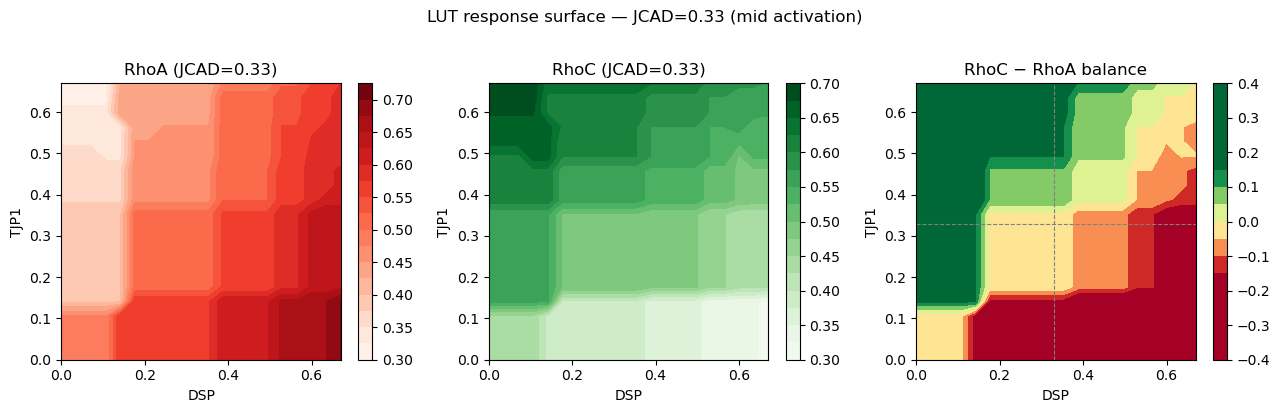

In [14]:
# Cell 8 — Sanity check LUT before running the cell
# Query the LUT at a few known points and confirm the outputs
# are directionally correct before trusting it in simulation.

print("=== LUT sanity checks ===\n")

# At rest — zero input
rA, rC = lut.query(0.0, 0.0, 0.0)
check("rest query matches stored rest values",
      abs(rA - lut.rhoa_rest) < 1e-3 and abs(rC - lut.rhoc_rest) < 1e-3,
      f"RhoA={rA:.3f} RhoC={rC:.3f}")

# High DSP + high JCAD, no TJP1 — should push RhoA up, RhoC down
rA_dsp, rC_dsp = lut.query(0.67, 0.0, 0.67)
check("high DSP+JCAD raises RhoA above rest",
      rA_dsp > lut.rhoa_rest,
      f"RhoA={rA_dsp:.3f} (rest={lut.rhoa_rest:.3f})")
check("high DSP+JCAD suppresses RhoC below rest",
      rC_dsp < lut.rhoc_rest,
      f"RhoC={rC_dsp:.3f} (rest={lut.rhoc_rest:.3f})")

# High TJP1 + high JCAD, no DSP — should push RhoC up, RhoA down
rA_tjp, rC_tjp = lut.query(0.0, 0.67, 0.67)
check("high TJP1+JCAD raises RhoC above rest",
      rC_tjp > lut.rhoc_rest,
      f"RhoC={rC_tjp:.3f} (rest={lut.rhoc_rest:.3f})")
check("high TJP1+JCAD suppresses RhoA below rest",
      rA_tjp < lut.rhoa_rest,
      f"RhoA={rA_tjp:.3f} (rest={lut.rhoa_rest:.3f})")

# All max — JCAD amplifies both, outcome depends on DSP vs TJP1 balance
rA_all, rC_all = lut.query(0.67, 0.67, 0.67)
print(f"\n  All inputs max (0.67): RhoA={rA_all:.3f}  RhoC={rC_all:.3f}")
print(f"  Net balance (RhoC-RhoA): {rC_all - rA_all:+.3f}")

# Plot LUT response surface — vary DSP and TJP1, JCAD fixed at 0.33
print("\n  Plotting LUT response surface...")
res   = 20
vals  = np.linspace(0, 0.67, res)
DSP_grid, TJP_grid = np.meshgrid(vals, vals)
RhoA_grid = np.zeros((res, res))
RhoC_grid = np.zeros((res, res))

for i in range(res):
    for j in range(res):
        RhoA_grid[i, j], RhoC_grid[i, j] = lut.query(
            DSP_grid[i, j], TJP_grid[i, j], 0.33
        )

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].contourf(DSP_grid, TJP_grid, RhoA_grid, levels=15, cmap='Reds')
axes[0].set_xlabel("DSP"); axes[0].set_ylabel("TJP1")
axes[0].set_title("RhoA (JCAD=0.33)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(DSP_grid, TJP_grid, RhoC_grid, levels=15, cmap='Greens')
axes[1].set_xlabel("DSP"); axes[1].set_ylabel("TJP1")
axes[1].set_title("RhoC (JCAD=0.33)")
plt.colorbar(im1, ax=axes[1])

balance = RhoC_grid - RhoA_grid
im2 = axes[2].contourf(DSP_grid, TJP_grid, balance, levels=15,
                        cmap='RdYlGn', vmin=-0.15, vmax=0.15)
axes[2].set_xlabel("DSP"); axes[2].set_ylabel("TJP1")
axes[2].set_title("RhoC − RhoA balance")
plt.colorbar(im2, ax=axes[2])
axes[2].axhline(0.33, color='gray', linestyle='--', linewidth=0.8)
axes[2].axvline(0.33, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle("LUT response surface — JCAD=0.33 (mid activation)", y=1.02)
plt.tight_layout()
plt.show()

## 2 Test Full Single Cell Run (WT)

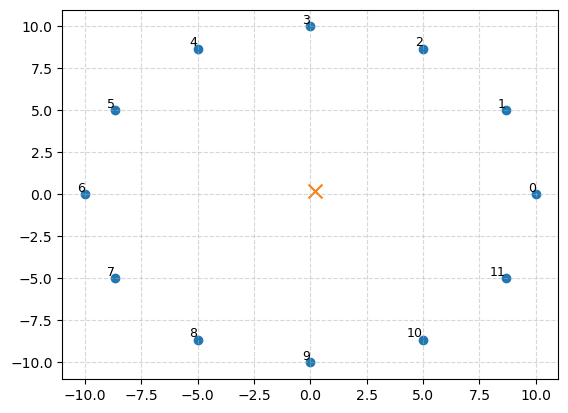

Starting: EndothelialCell(id=0 | n=12 | centroid=[-0.  0.] | ar=1.00 | area_err=1.000 | rho_bal=+0.000 | lsf=1.000 | t_sf=0.0000)

  step    0: EndothelialCell(id=0 | n=12 | centroid=[0.05 0.  ] | ar=1.00 | area_err=0.995 | rho_bal=-0.026 | lsf=1.000 | t_sf=0.0000)
  step    0: EndothelialCell(id=0 | n=12 | centroid=[0.05 0.  ] | ar=1.00 | area_err=0.995 | rho_bal=-0.026 | lsf=1.000 | t_sf=0.0000) | lateral springs stretched: 3/~4
  step  100: EndothelialCell(id=0 | n=12 | centroid=[5.05 0.  ] | ar=1.57 | area_err=0.989 | rho_bal=-0.013 | lsf=0.976 | t_sf=0.0722)
  step  100: EndothelialCell(id=0 | n=12 | centroid=[5.05 0.  ] | ar=1.57 | area_err=0.989 | rho_bal=-0.013 | lsf=0.976 | t_sf=0.0722) | lateral springs stretched: 0/~4
  step  200: EndothelialCell(id=0 | n=12 | centroid=[10.05  0.  ] | ar=2.16 | area_err=0.983 | rho_bal=-0.007 | lsf=0.916 | t_sf=0.2572)
  step  200: EndothelialCell(id=0 | n=12 | centroid=[10.05  0.  ] | ar=2.16 | area_err=0.983 | rho_bal=-0.007 | lsf=0.916 | 

True

In [15]:
# Cell 9 — Full single cell run with real LUT, 500 steps

flow = FlowField(magnitude=3)
cell = EndothelialCell(
    cell_id=0,
    centroid=np.array([0.0, 0.0]),
    lut=lut, cfg=spatial_cfg,
    n_nodes=12, radius=10.0
)
plot_cell(cell)

print(f"Starting: {cell}\n")
      
history = []
for t in range(500):
      cell.step(flow, dt=0.1)
      if t % 10 == 0:
            s = cell.get_state()
            s['step'] = t
            history.append(s)
            if t % 100 == 0:
                  print(f"  step {t:4d}: {cell}")
      if t % 100 == 0: 
            lateral_stretched = sum(1 for s in cell.springs
                       if s.alignment > 0.5 and s.L_current > s.L_cortex)
            print(f"  step {t:4d}: {cell} | lateral springs stretched: {lateral_stretched}/~4")
        

final = history[-1]
print(f"\nFinal: {cell}")

# Pass/fail checks
print("\n--- Checks ---")
check("AR > 1.3 at steady state",
      final['metrics']['ar'] > 1.3,
      f"ar={final['metrics']['ar']}")
check("area_err within 15%",
      abs(final['metrics']['area_err'] - 1.0) < 0.15,
      f"area_err={final['metrics']['area_err']}")
check("L_sf has shortened on lateral springs",
      final['remodelling']['mean_lsf_ratio'] < 1.0,
      f"lsf={final['remodelling']['mean_lsf_ratio']:.4f}")
check("rho_balance not strongly negative",
      final['signalling']['rho_balance'] > -0.05,
      f"balance={final['signalling']['rho_balance']}")

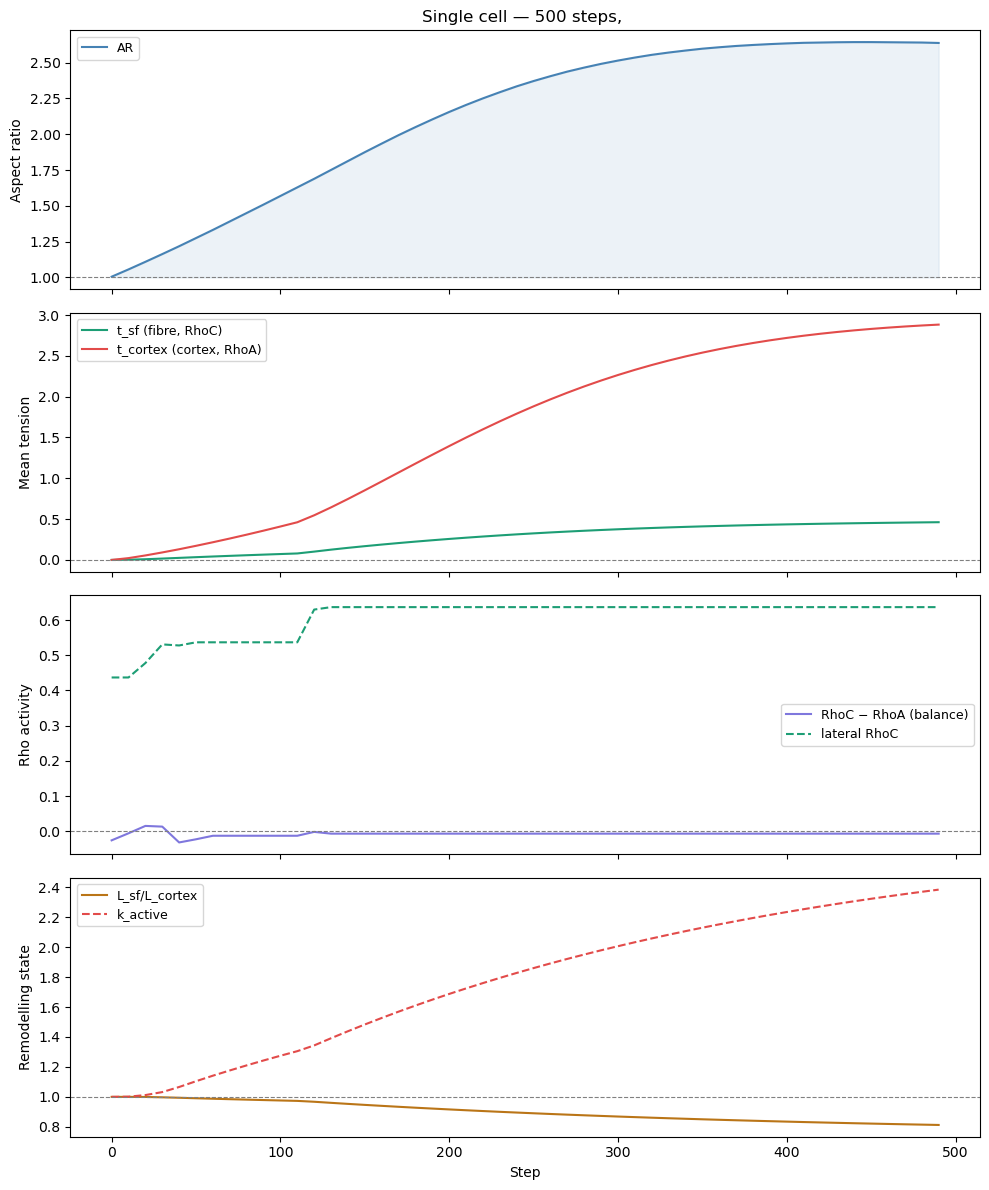

In [16]:
# Cell 10 — Plot full run results

plot_run_results(history)


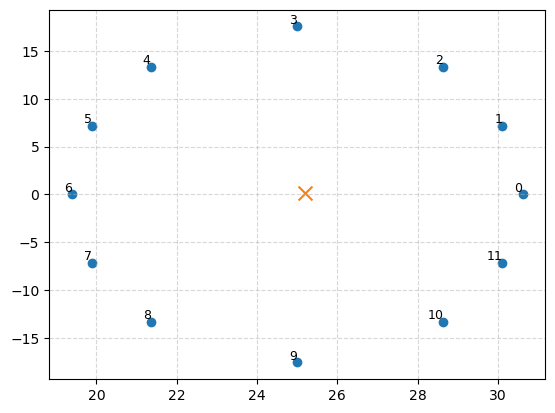

In [17]:
plot_cell(cell)

### Diagnostics: Spring Tensions

In [18]:
# Print actual spring tensions and lengths at step 50
cell_check = EndothelialCell(0, np.array([0.0, 0.0]),
                             lut=lut, cfg=spatial_cfg,
                             n_nodes=12, radius=10.0)
flow_check = FlowField(magnitude=2.0)

for _ in range(50):
    cell_check.step(flow_check, dt=0.1)

print(f"{'id':>3} {'align':>6} {'L_cur':>7} {'L_cort':>7} {'stretch%':>9} {'tau_dsp':>8} {'tau_tjp':>8} {'tau_jcad':>9}")
for s in cell_check.springs:
    stretch_pct = (s.L_current - s.L_cortex) / s.L_cortex * 100
    tensile = max(s.tension_total, 0)
    tau_dsp  = tensile
    tau_tjp1 = tensile * (1 - s.alignment)
    tau_jcad = tensile * s.alignment
    print(f"{s.id:>3} {s.alignment:>6.3f} {s.L_current:>7.3f} {s.L_cortex:>7.3f} "
          f"{stretch_pct:>8.2f}% {tau_dsp:>8.4f} {tau_tjp1:>8.4f} {tau_jcad:>9.4f}")

 id  align   L_cur  L_cort  stretch%  tau_dsp  tau_tjp  tau_jcad
  0  0.206   5.394   5.176     4.20%   0.2709   0.2150    0.0559
  1  0.630   5.245   5.176     1.33%   0.1127   0.0417    0.0711
  2  0.952   4.928   5.176    -4.81%   0.0000   0.0000    0.0000
  3  0.952   4.928   5.176    -4.81%   0.0000   0.0000    0.0000
  4  0.630   5.245   5.176     1.33%   0.1127   0.0417    0.0711
  5  0.206   5.394   5.176     4.20%   0.2709   0.2150    0.0559
  6  0.206   5.394   5.176     4.20%   0.2709   0.2150    0.0559
  7  0.630   5.245   5.176     1.33%   0.1127   0.0417    0.0711
  8  0.952   4.928   5.176    -4.81%   0.0000   0.0000    0.0000
  9  0.952   4.928   5.176    -4.81%   0.0000   0.0000    0.0000
 10  0.630   5.245   5.176     1.33%   0.1127   0.0417    0.0711
 11  0.206   5.394   5.176     4.20%   0.2709   0.2150    0.0559


### Diagnostics: Rho LUT

In [19]:
# What protein values are actually reaching the LUT?
cell_diag = EndothelialCell(0, np.array([0.0, 0.0]),
                            lut=lut, cfg=spatial_cfg,
                            n_nodes=12, radius=10.0)
flow_diag = FlowField(magnitude=4.0)

for node in cell.nodes:
      node.pos *= 1.05

for _ in range(100):
    cell_diag.step(flow_diag, dt=0.1)

print(f"{'id':>3} {'align':>6} {'tension':>8} {'DSP':>6} {'TJP1':>6} {'JCAD':>6} {'RhoA':>6} {'RhoC':>6}")
for s in cell_diag.springs:
    print(f"{s.id:>3} {s.alignment:>6.3f} {s.tension_total:>8.4f} "
          f"{s.DSP:>6.3f} {s.TJP1:>6.3f} {s.JCAD:>6.3f} "
          f"{s.P_RhoA:>6.3f} {s.P_RhoC:>6.3f}")

 id  align  tension    DSP   TJP1   JCAD   RhoA   RhoC
  0  0.072   1.4375  0.670  0.670  0.655  0.644  0.637
  1  0.343   0.7504  0.670  0.669  0.670  0.644  0.637
  2  0.856  -0.0020  0.000  0.000  0.000  0.463  0.437
  3  0.856  -0.0020  0.000  0.000  0.000  0.463  0.437
  4  0.343   0.7504  0.670  0.669  0.670  0.644  0.637
  5  0.072   1.4375  0.670  0.670  0.655  0.644  0.637
  6  0.072   1.4375  0.670  0.670  0.655  0.644  0.637
  7  0.343   0.7504  0.670  0.669  0.670  0.644  0.637
  8  0.856  -0.0020  0.000  0.000  0.000  0.463  0.437
  9  0.856  -0.0020  0.000  0.000  0.000  0.463  0.437
 10  0.343   0.7504  0.670  0.669  0.670  0.644  0.637
 11  0.072   1.4375  0.670  0.670  0.655  0.644  0.637


In [20]:
# What RhoC does the LUT return for lateral spring inputs?
# Lateral spring: high DSP, low TJP1, varying JCAD
print("Lateral spring LUT outputs (high DSP=0.5, TJP1 varies, JCAD varies):")
print(f"{'TJP1':>6} {'JCAD':>6} {'RhoA':>6} {'RhoC':>6} {'delta_rhoC':>10} {'balance':>8}")
for tjp1 in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for jcad in [0.0, 0.3, 0.6]:
        rA, rC = lut.query(0.5, tjp1, jcad)
        delta = max(rC - lut.rhoc_rest, 0.0)
        print(f"{tjp1:>6.2f} {jcad:>6.2f} {rA:>6.3f} {rC:>6.3f} {delta:>10.4f} {rC-rA:>8.3f}")
    print()

Lateral spring LUT outputs (high DSP=0.5, TJP1 varies, JCAD varies):
  TJP1   JCAD   RhoA   RhoC delta_rhoC  balance
  0.00   0.00  0.575  0.394     0.0000   -0.181
  0.00   0.30  0.621  0.363     0.0000   -0.258
  0.00   0.60  0.694  0.320     0.0000   -0.374

  0.10   0.00  0.554  0.400     0.0000   -0.154
  0.10   0.30  0.621  0.363     0.0000   -0.258
  0.10   0.60  0.694  0.320     0.0000   -0.374

  0.20   0.00  0.518  0.463     0.0260   -0.055
  0.20   0.30  0.594  0.452     0.0150   -0.142
  0.20   0.60  0.652  0.462     0.0250   -0.190

  0.30   0.00  0.539  0.453     0.0160   -0.086
  0.30   0.30  0.556  0.481     0.0440   -0.075
  0.30   0.60  0.652  0.462     0.0250   -0.190

  0.40   0.00  0.515  0.485     0.0480   -0.030
  0.40   0.30  0.564  0.512     0.0750   -0.052
  0.40   0.60  0.621  0.543     0.1060   -0.078

  0.50   0.00  0.488  0.520     0.0830    0.032
  0.50   0.30  0.551  0.550     0.1130   -0.001
  0.50   0.60  0.542  0.623     0.1860    0.081



In [21]:
# Quick check — what is tau_tjp1 on a lateral spring at runtime?
for s in cell.springs:
    if s.alignment > 0.8:
        tensile = max(s.tension_total, 0.0)
        tau_tjp1 = abs(s.tension_total) * (1.0 - s.alignment)  # with abs() change
        from abm.spring import get_protein_recruitment
        tjp1_val = get_protein_recruitment(spatial_cfg, tau_tjp1, 'TJP1')
        print(f"spring {s.id}: tension={s.tension_total:.4f} align={s.alignment:.3f} "
              f"tau_tjp1={tau_tjp1:.4f} TJP1={tjp1_val:.4f} "
              f"P_RhoC={s.P_RhoC:.4f}")

## 3 Test Full Pipeline Knockouts

In [39]:
flow = FlowField(magnitude=5)

#### Perturbation WT

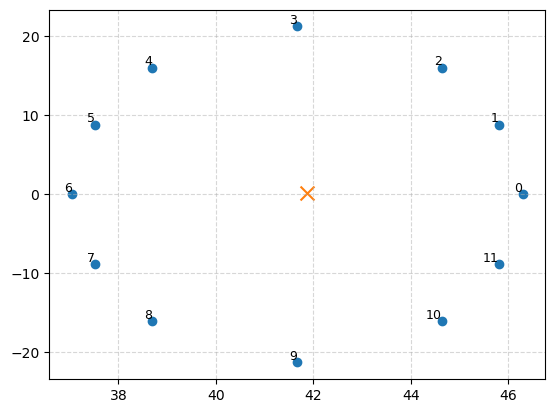

In [40]:
cell_wt = EndothelialCell(
    cell_id=0,
    centroid=np.array([0.0, 0.0]),
    lut=lut, cfg=spatial_cfg,
    n_nodes=12, radius=10.0
)
plot_cell(cell)

Starting: EndothelialCell(id=0 | n=12 | centroid=[-0.  0.] | ar=1.00 | area_err=1.000 | rho_bal=+0.000 | lsf=1.000 | t_sf=0.0000)

  step    0: EndothelialCell(id=0 | n=12 | centroid=[0.08 0.  ] | ar=1.01 | area_err=0.992 | rho_bal=-0.026 | lsf=1.000 | t_sf=0.0000)
  step    0: EndothelialCell(id=0 | n=12 | centroid=[0.08 0.  ] | ar=1.01 | area_err=0.992 | rho_bal=-0.026 | lsf=1.000 | t_sf=0.0000) | lateral springs stretched: 3/~4
  step  100: EndothelialCell(id=0 | n=12 | centroid=[ 8.42 -0.  ] | ar=2.06 | area_err=0.979 | rho_bal=-0.016 | lsf=0.972 | t_sf=0.1477)
  step  100: EndothelialCell(id=0 | n=12 | centroid=[ 8.42 -0.  ] | ar=2.06 | area_err=0.979 | rho_bal=-0.016 | lsf=0.972 | t_sf=0.1477) | lateral springs stretched: 4/~4
  step  200: EndothelialCell(id=0 | n=12 | centroid=[16.75  0.  ] | ar=3.13 | area_err=0.969 | rho_bal=-0.007 | lsf=0.908 | t_sf=0.4210)
  step  200: EndothelialCell(id=0 | n=12 | centroid=[16.75  0.  ] | ar=3.13 | area_err=0.969 | rho_bal=-0.007 | lsf=0.90

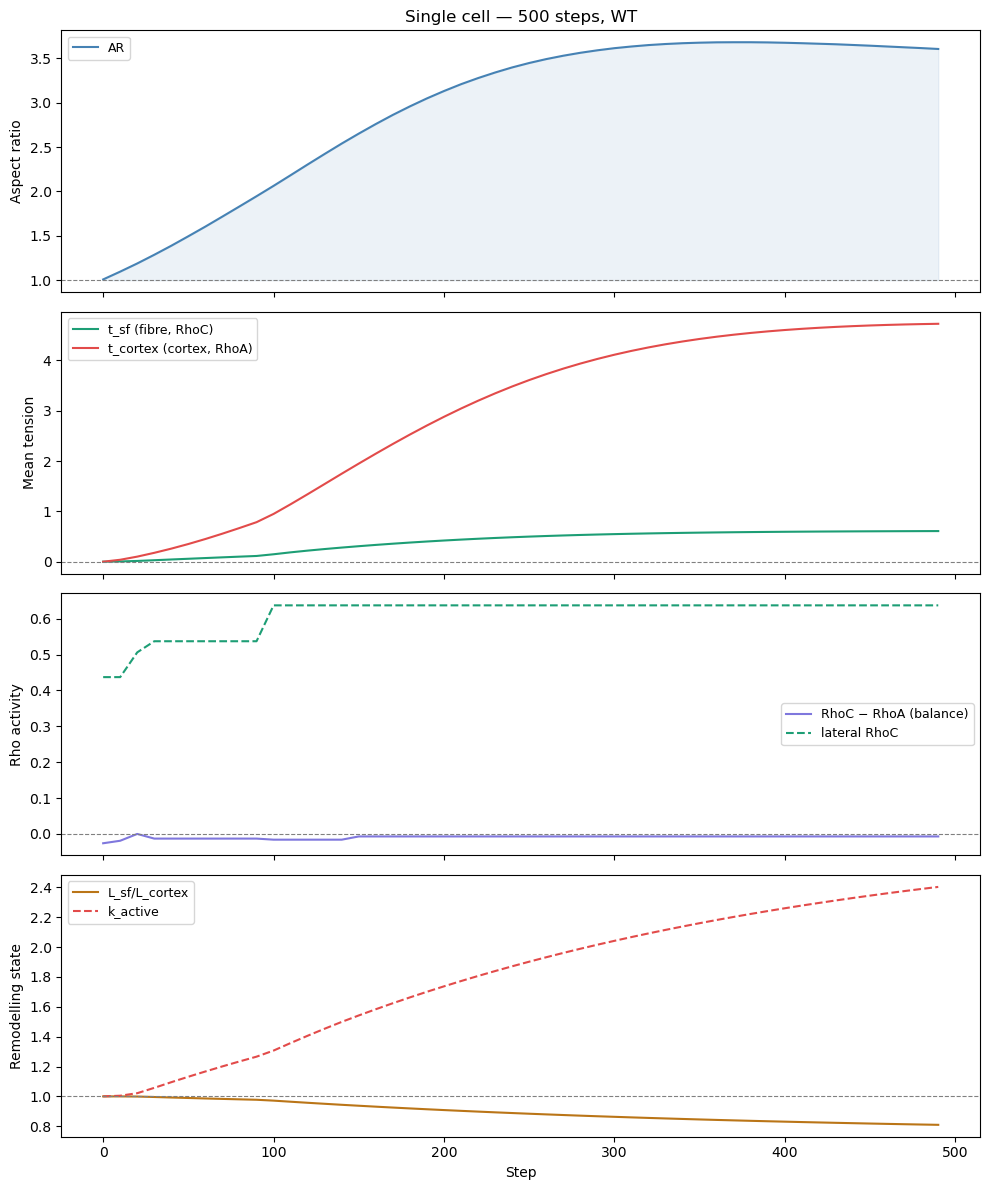

In [ ]:

his_wt = run_single_cell_sim(cell_wt, flow)
plot_cell(cell_wt)
plot_run_results(his_wt, 'WT')

#### Perturbation DSP KO

In [25]:
cfg_dsp_ko = copy.deepcopy(spatial_cfg)
cfg_dsp_ko['hill_params']['DSP']['knocked_out'] = True

cell_dsp_ko = EndothelialCell(
    cell_id=1,
    centroid=np.array([0.0, 0.0]),
    lut=lut, cfg=cfg_dsp_ko,
    n_nodes=12, radius=10.0
)


Starting: EndothelialCell(id=1 | n=12 | centroid=[83.33 -0.  ] | ar=6.49 | area_err=0.964 | rho_bal=+0.541 | lsf=0.665 | t_sf=1.0809)

  step    0: EndothelialCell(id=1 | n=12 | centroid=[83.42 -0.  ] | ar=6.49 | area_err=0.964 | rho_bal=+0.541 | lsf=0.665 | t_sf=1.0810)
  step    0: EndothelialCell(id=1 | n=12 | centroid=[83.42 -0.  ] | ar=6.49 | area_err=0.964 | rho_bal=+0.541 | lsf=0.665 | t_sf=1.0810) | lateral springs stretched: 0/~4
  step  100: EndothelialCell(id=1 | n=12 | centroid=[91.75 -0.  ] | ar=6.50 | area_err=0.964 | rho_bal=+0.541 | lsf=0.661 | t_sf=1.0868)
  step  100: EndothelialCell(id=1 | n=12 | centroid=[91.75 -0.  ] | ar=6.50 | area_err=0.964 | rho_bal=+0.541 | lsf=0.661 | t_sf=1.0868) | lateral springs stretched: 0/~4
  step  200: EndothelialCell(id=1 | n=12 | centroid=[100.08  -0.  ] | ar=6.50 | area_err=0.964 | rho_bal=+0.541 | lsf=0.658 | t_sf=1.0907)
  step  200: EndothelialCell(id=1 | n=12 | centroid=[100.08  -0.  ] | ar=6.50 | area_err=0.964 | rho_bal=+0.54

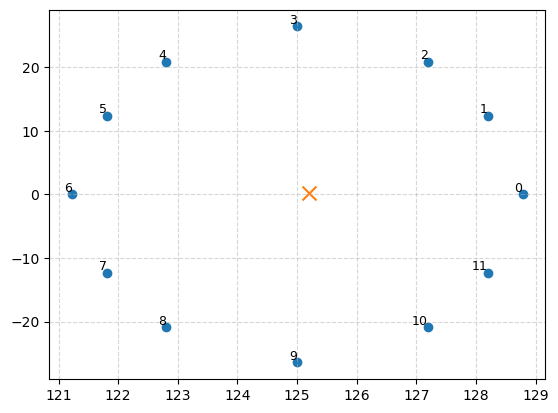

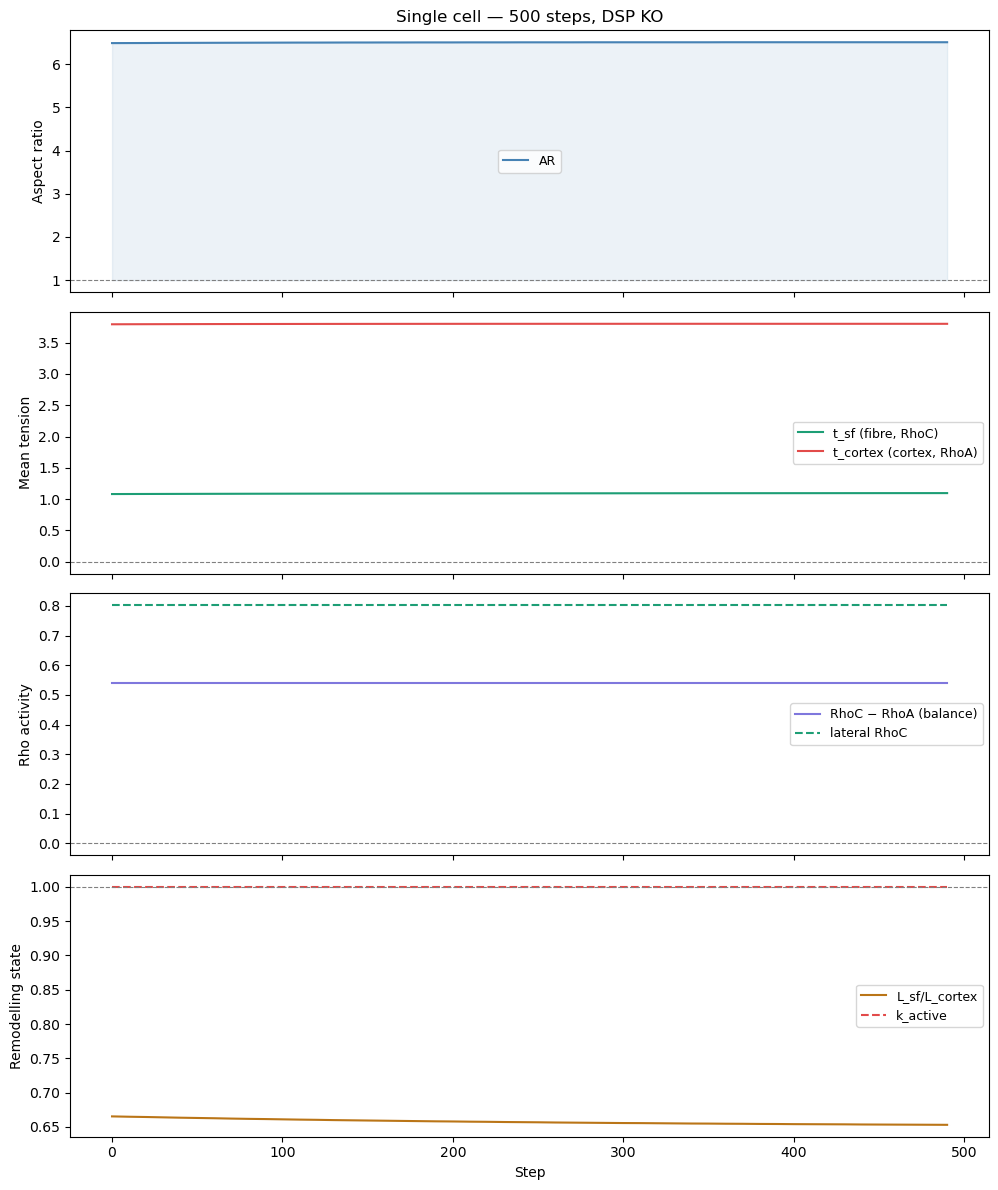

In [37]:

his_dsp_ko = run_single_cell_sim(cell_dsp_ko, flow)
plot_cell(cell_dsp_ko)
plot_run_results(his_dsp_ko, 'DSP KO')

#### Perturbation: TJP1 KO

In [27]:
cfg_tjp1_ko = copy.deepcopy(spatial_cfg)
cfg_tjp1_ko['hill_params']['TJP1']['knocked_out'] = True

cell_tjp1_ko = EndothelialCell(
    cell_id=1,
    centroid=np.array([0.0, 0.0]),
    lut=lut, cfg=cfg_tjp1_ko,
    n_nodes=12, radius=10.0
)

Starting: EndothelialCell(id=1 | n=12 | centroid=[41.67  0.  ] | ar=2.92 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2871)

  step    0: EndothelialCell(id=1 | n=12 | centroid=[41.75  0.  ] | ar=2.92 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2869)
  step    0: EndothelialCell(id=1 | n=12 | centroid=[41.75  0.  ] | ar=2.92 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2869) | lateral springs stretched: 4/~4
  step  100: EndothelialCell(id=1 | n=12 | centroid=[50.08  0.  ] | ar=2.83 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2710)
  step  100: EndothelialCell(id=1 | n=12 | centroid=[50.08  0.  ] | ar=2.83 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2710) | lateral springs stretched: 4/~4
  step  200: EndothelialCell(id=1 | n=12 | centroid=[58.42  0.  ] | ar=2.76 | area_err=0.960 | rho_bal=-0.538 | lsf=1.000 | t_sf=0.2603)
  step  200: EndothelialCell(id=1 | n=12 | centroid=[58.42  0.  ] | ar=2.76 | area_err=0.960 | rho_bal=-0.538 | 

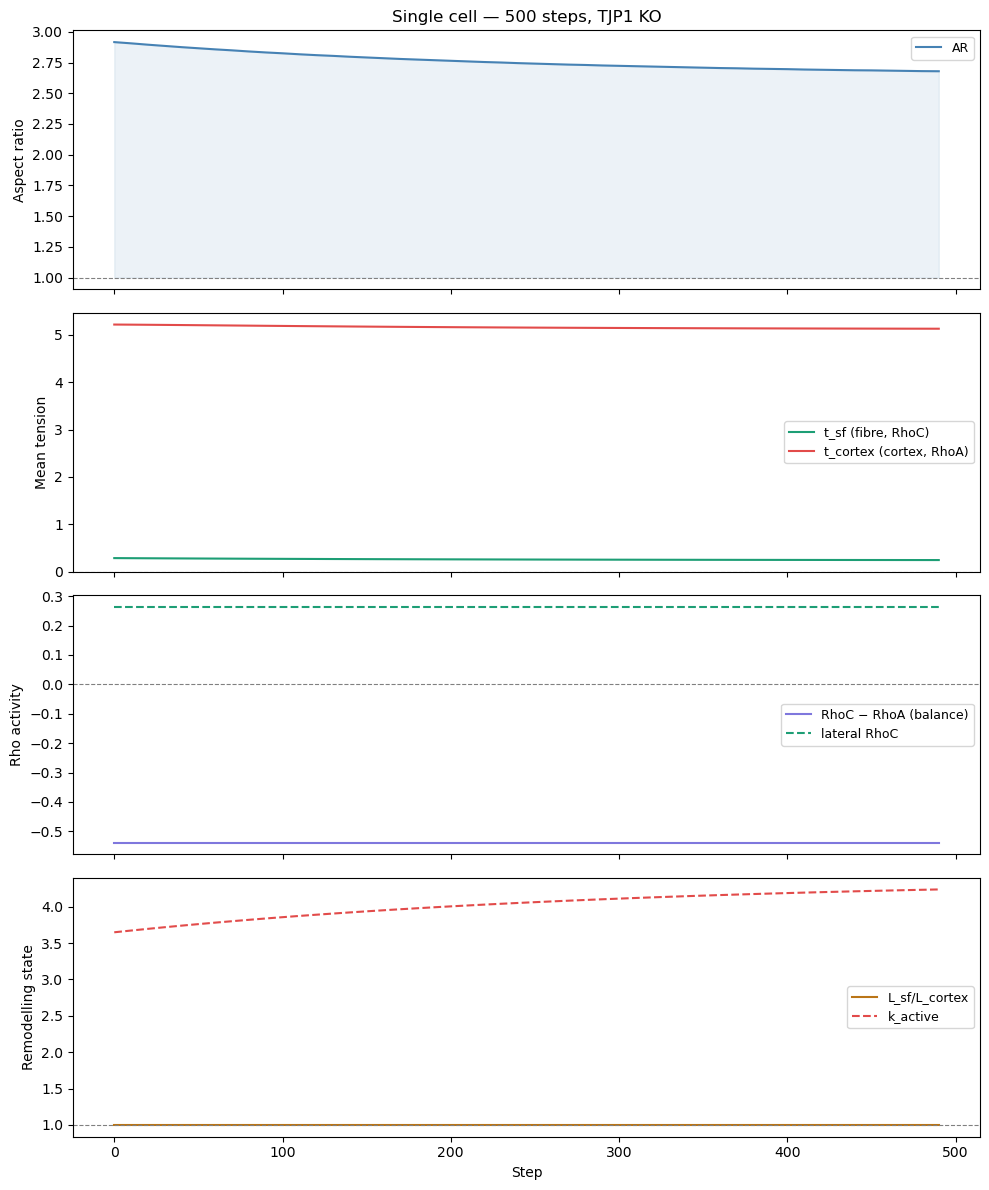

In [35]:
his_tjp1_ko = run_single_cell_sim(cell_tjp1_ko, flow)
#plot_cell(cell_tjp1_ko)
plot_run_results(his_tjp1_ko, 'TJP1 KO')

## 4 Full Run Setup + Phenotypes

In [29]:
conditions = {
    'WT':       spatial_cfg,
    'DSP_KO':   {**copy.deepcopy(spatial_cfg),
                 'hill_params': {**copy.deepcopy(spatial_cfg['hill_params']),
                 'DSP': {**spatial_cfg['hill_params']['DSP'], 'knocked_out': True}}},
    'DSP_JCAD_DKO':   {**copy.deepcopy(spatial_cfg),
                 'hill_params': {**copy.deepcopy(spatial_cfg['hill_params']),
                 'DSP': {**spatial_cfg['hill_params']['DSP'], 'knocked_out': True},
                 'JCAD': {**spatial_cfg['hill_params']['JCAD'], 'knocked_out': True}}},
    'TJP1_KO':  {**copy.deepcopy(spatial_cfg),
                 'hill_params': {**copy.deepcopy(spatial_cfg['hill_params']),
                 'TJP1': {**spatial_cfg['hill_params']['TJP1'], 'knocked_out': True}}},
    'TJP1_JCAD_DKO':  {**copy.deepcopy(spatial_cfg),
                 'hill_params': {**copy.deepcopy(spatial_cfg['hill_params']),
                 'TJP1': {**spatial_cfg['hill_params']['TJP1'], 'knocked_out': True},
                 'JCAD': {**spatial_cfg['hill_params']['JCAD'], 'knocked_out': True}}},
}

In [30]:
flow = FlowField(magnitude=5.0)
results = {}

for name, cfg in conditions.items():
    cell = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=cfg,
                           n_nodes=12, radius=10.0)
    for _ in range(500):
        cell.step(flow, dt=0.1)
    #plot_cell(cell)

    s = cell.get_state()
    s['phenotype'] = classify_phenotype(s)
    results[name] = s
    print(f"{name:10s}: AR={s['metrics']['ar']:.3f} | "
          f"balance={s['signalling']['rho_balance']:+.3f} | "
          f"lsf={s['remodelling']['mean_lsf_ratio']:.3f} | "
          f"k={s['remodelling']['mean_k_active']:.3f} | "
          f"phenotype={s['phenotype']}")

WT        : AR=3.597 | balance=-0.007 | lsf=0.808 | k=2.415 | phenotype=normal
DSP_KO    : AR=5.898 | balance=+0.541 | lsf=0.732 | k=1.000 | phenotype=hyper
DSP_JCAD_DKO: AR=5.953 | balance=+0.239 | lsf=0.839 | k=1.000 | phenotype=normal
TJP1_KO   : AR=2.917 | balance=-0.538 | lsf=1.000 | k=3.646 | phenotype=failed
TJP1_JCAD_DKO: AR=3.914 | balance=-0.236 | lsf=1.000 | k=2.118 | phenotype=normal


### Diagnostics

In [ ]:
cfg_dsp = copy.deepcopy(spatial_cfg)
cfg_dsp['hill_params']['DSP']['knocked_out'] = True
cell_dsp = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=cfg_dsp, n_nodes=12, radius=10.0)
#plot_cell(cell)
flow = FlowField(magnitude=5.0)

    
for i in range(500):
    
    cell_dsp.step(flow, dt=0.1)


print("DSP-KO lateral springs at steady state:")
print(f"{'id':>3} {'align':>6} {'P_RhoC':>7} {'rhoC_rest':>10} "
      f"{'delta_rhoC':>11} {'L_sf':>7} {'L_cort':>7} {'L_cur':>7}")
for s in cell_dsp.springs:
    delta = max(s.P_RhoC - lut.rhoc_rest, 0.0)
    print(f"{s.id:>3} {s.alignment:>6.3f} {s.P_RhoC:>7.4f} "
            f"{lut.rhoc_rest:>10.4f} {delta:>11.4f} "
            f"{s.L_sf:>7.4f} {s.L_cortex:>7.4f} {s.L_current:>7.4f}")


DSP-KO lateral springs at steady state:
 id  align  P_RhoC  rhoC_rest  delta_rhoC    L_sf  L_cort   L_cur
  0  0.044  0.8020     0.4370      0.3650  4.6006  5.1764 11.6779
  1  0.120  0.8020     0.4370      0.3650  3.7285  5.1764  8.2790
  2  0.400  0.8020     0.4370      0.3650  3.8471  5.1764  5.9489
  3  0.400  0.8020     0.4370      0.3650  3.8471  5.1764  5.9489
  4  0.120  0.8020     0.4370      0.3650  3.7285  5.1764  8.2790
  5  0.044  0.8020     0.4370      0.3650  4.6006  5.1764 11.6779
  6  0.044  0.8020     0.4370      0.3650  4.6006  5.1764 11.6779
  7  0.120  0.8020     0.4370      0.3650  3.7285  5.1764  8.2790
  8  0.400  0.8020     0.4370      0.3650  3.8471  5.1764  5.9489
  9  0.400  0.8020     0.4370      0.3650  3.8471  5.1764  5.9489
 10  0.120  0.8020     0.4370      0.3650  3.7285  5.1764  8.2790
 11  0.044  0.8020     0.4370      0.3650  4.6006  5.1764 11.6779


In [32]:
# What AR does a completely passive cell reach with no signalling?
# This is your mechanical upper bound
class PassiveLUT:
    rhoa_rest = 0.463
    rhoc_rest = 0.437
    def query(self, d, t, j):
        return self.rhoa_rest, self.rhoc_rest  # always return rest values

cell_passive = EndothelialCell(0, np.array([0.0, 0.0]),
                               lut=PassiveLUT(), cfg=spatial_cfg,
                               n_nodes=12, radius=10.0)
flow = FlowField(magnitude=5.0)
for _ in range(500):
    cell_passive.step(flow, dt=0.1)

s = cell_passive.get_state()
print(f"Passive cell (no remodelling): AR={s['metrics']['ar']:.3f}")
print(f"DSP-KO (k=1, max RhoC):        AR=6.493")
print(f"Target WT:                      AR=5.592")

Passive cell (no remodelling): AR=6.008
DSP-KO (k=1, max RhoC):        AR=6.493
Target WT:                      AR=5.592


In [33]:
# What force is t_sf actually contributing vs what it needs to contribute?
cfg_dsp = copy.deepcopy(spatial_cfg)
cfg_dsp['hill_params']['DSP']['knocked_out'] = True
cell_dsp = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=cfg_dsp, n_nodes=12, radius=10.0)
flow = FlowField(magnitude=5.0)

for _ in range(500):
    cell_dsp.step(flow, dt=0.1)

print("DSP-KO force audit:")
for s in cell_dsp.springs:
    if s._init_alignment > 0.5:
        prestretch = s.L_current - s.L_sf
        print(f"spring {s.id}: align_init={s._init_alignment:.3f} "
              f"L_cur={s.L_current:.3f} L_sf={s.L_sf:.3f} "
              f"prestretch={prestretch:.3f} "
              f"t_sf={s.tension_sf:.4f} "
              f"k_sf={s.k_sf:.4f}")
print(f"\nFor fibres to add 10% AR above passive, need t_sf ~ {0.1 * 1.0:.3f}")
print(f"Current mean t_sf on lateral springs: "
      f"{sum(s.tension_sf for s in cell_dsp.springs if s._init_alignment > 0.5) / max(1, sum(1 for s in cell_dsp.springs if s._init_alignment > 0.5)):.4f}")

DSP-KO force audit:
spring 1: align_init=0.707 L_cur=8.279 L_sf=3.729 prestretch=4.550 t_sf=1.2867 k_sf=0.4000
spring 2: align_init=0.966 L_cur=5.949 L_sf=3.847 prestretch=2.102 t_sf=0.8114 k_sf=0.4000
spring 3: align_init=0.966 L_cur=5.949 L_sf=3.847 prestretch=2.102 t_sf=0.8114 k_sf=0.4000
spring 4: align_init=0.707 L_cur=8.279 L_sf=3.729 prestretch=4.550 t_sf=1.2867 k_sf=0.4000
spring 7: align_init=0.707 L_cur=8.279 L_sf=3.729 prestretch=4.550 t_sf=1.2867 k_sf=0.4000
spring 8: align_init=0.966 L_cur=5.949 L_sf=3.847 prestretch=2.102 t_sf=0.8114 k_sf=0.4000
spring 9: align_init=0.966 L_cur=5.949 L_sf=3.847 prestretch=2.102 t_sf=0.8114 k_sf=0.4000
spring 10: align_init=0.707 L_cur=8.279 L_sf=3.729 prestretch=4.550 t_sf=1.2867 k_sf=0.4000

For fibres to add 10% AR above passive, need t_sf ~ 0.100
Current mean t_sf on lateral springs: 1.0491


In [34]:
# Verify t_sf calculation matches spring code
s_check = cell_dsp.springs[1]
expected = s_check.k_sf * (s_check.L_current - s_check.L_sf) * s_check._init_alignment
print(f"Expected t_sf: {expected:.4f}")
print(f"Actual t_sf:   {s_check.tension_sf:.4f}")
print(f"k_sf: {s_check.k_sf:.4f}")
print(f"alignment (current): {s_check.alignment:.4f}")
print(f"alignment (init):    {s_check._init_alignment:.4f}")

Expected t_sf: 1.2871
Actual t_sf:   1.2867
k_sf: 0.4000
alignment (current): 0.1196
alignment (init):    0.7071
